# Análisis geoespacial

In [1]:
from eda_utils import *   # carga y prepara la base (capítulo 1)

Los mapas usan de fondo el mapa de Barranquilla de OpenStreetMap, que se descarga la
primera vez y queda guardado. El mapa de estratos es interactivo.

In [2]:
geo = viv[viv.lat.between(10.90, 11.05) & viv.lon.between(-74.92, -74.75)].copy()
print("viviendas en el mapa:", len(geo))
ASPECTO = 1 / np.cos(np.deg2rad(geo.lat.mean()))

MAPA = dict(center={"lat": 10.985, "lon": -74.815}, zoom=11.4, map_style="carto-positron", height=620)
ESCALA_PRECIO = ["#313695", "#4575B4", "#74ADD1", "#FDAE61", "#F46D43", "#A50026"]

def ajustar(fig, titulo):
    fig.update_layout(title=dict(text=titulo), margin=dict(l=0, r=0, t=60, b=0))
    return fig

viviendas en el mapa: 15459


In [3]:
# Mapa de fondo de Barranquilla (calles, barrios y río) de OpenStreetMap.
# Se descarga la primera vez y queda guardado en mapa_base_barranquilla.png.
import io, math, urllib.request
from pathlib import Path
from PIL import Image

EXTENSION = (-74.90, -74.755, 10.91, 11.05)   # lon mín, lon máx, lat mín, lat máx

def _a_tesela(lon, lat, z):
    n = 2 ** z
    return (lon + 180) / 360 * n, (1 - math.asinh(math.tan(math.radians(lat))) / math.pi) / 2 * n

def _a_lonlat(x, y, z):
    n = 2 ** z
    return x / n * 360 - 180, math.degrees(math.atan(math.sinh(math.pi * (1 - 2 * y / n))))

def mapa_base(z=14, archivo="datos/mapa_base_barranquilla.png"):
    x0, y0 = _a_tesela(EXTENSION[0], EXTENSION[3], z)
    x1, y1 = _a_tesela(EXTENSION[1], EXTENSION[2], z)
    xs, ys = range(int(x0), int(x1) + 1), range(int(y0), int(y1) + 1)
    lon_min, lat_max = _a_lonlat(xs[0], ys[0], z)
    lon_max, lat_min = _a_lonlat(xs[-1] + 1, ys[-1] + 1, z)
    ruta = Path(archivo)
    if not ruta.exists():
        img = Image.new("RGB", (256 * len(xs), 256 * len(ys)))
        for i, x in enumerate(xs):
            for j, y in enumerate(ys):
                url = f"https://tile.openstreetmap.org/{z}/{x}/{y}.png"
                pedido = urllib.request.Request(url, headers={"User-Agent": "EDA-seminario-vivienda-barranquilla/1.0"})
                tesela = Image.open(io.BytesIO(urllib.request.urlopen(pedido, timeout=30).read()))
                img.paste(tesela.convert("RGB"), (256 * i, 256 * j))
        img.save(ruta)
    return np.asarray(Image.open(ruta)), (lon_min, lon_max, lat_min, lat_max)

FONDO, EXTENSION_FONDO = mapa_base()

def poner_fondo(ax):
    ax.imshow(FONDO, extent=EXTENSION_FONDO, zorder=0, interpolation="lanczos", alpha=0.75)
    ax.set_xlim(EXTENSION[0], EXTENSION[1])
    ax.set_ylim(EXTENSION[2], EXTENSION[3])
    ax.set_aspect(ASPECTO)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    for lado in ax.spines.values():
        lado.set_visible(False)
    ax.text(0.99, 0.01, "© colaboradores de OpenStreetMap", transform=ax.transAxes,
            fontsize=6, ha="right", va="bottom", color="#555")

## Dónde están las ventas

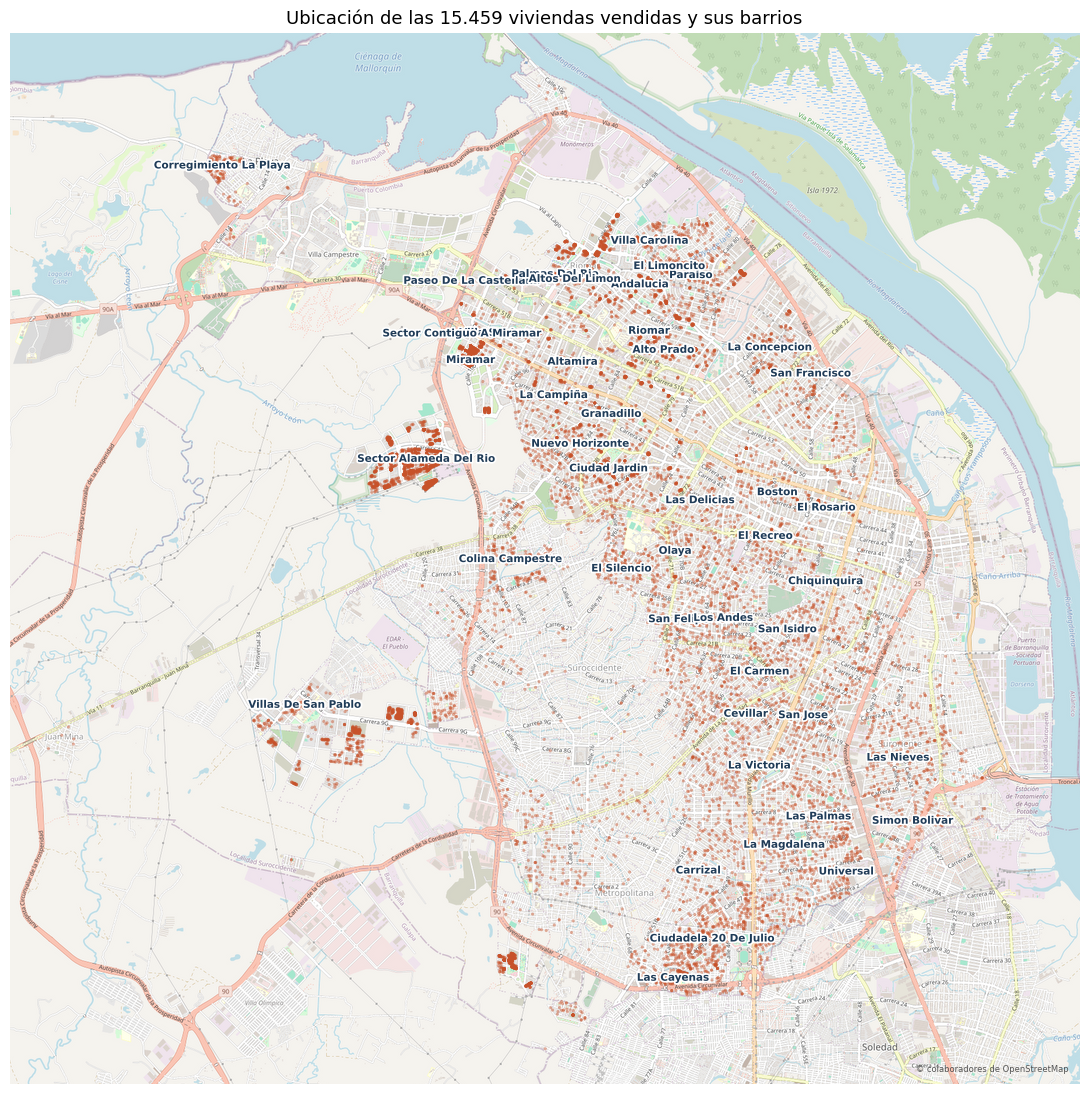

In [4]:
fig, ax = plt.subplots(figsize=(11, 11))
poner_fondo(ax)
ax.scatter(geo.lon, geo.lat, s=5, color="#C7522A", alpha=0.45, edgecolors="none", zorder=2)

# nombre de los 45 barrios con más ventas, en el centro de sus compras
nombres = (geo[geo.barrio.notna() & ~geo.barrio.isin(NO_BARRIOS)]
           .groupby("barrio").agg(lat=("lat", "median"), lon=("lon", "median"), n=("precio", "size"))
           .nlargest(45, "n"))
for barrio, pos in nombres.iterrows():
    ax.text(pos.lon, pos.lat, barrio.title(), fontsize=7.5, fontweight="bold", ha="center",
            va="center", color="#1F3B57", zorder=3,
            path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

ax.set_title(f"Ubicación de las {len(geo):,} viviendas vendidas y sus barrios".replace(",", "."), fontsize=13)
plt.tight_layout()
plt.show()

Las ventas se concentran en el norte (Riomar, Norte-Centro Histórico), en el
suroccidente y en proyectos aislados como Alameda del Río y Villas de San Pablo.

## Precio en el mapa

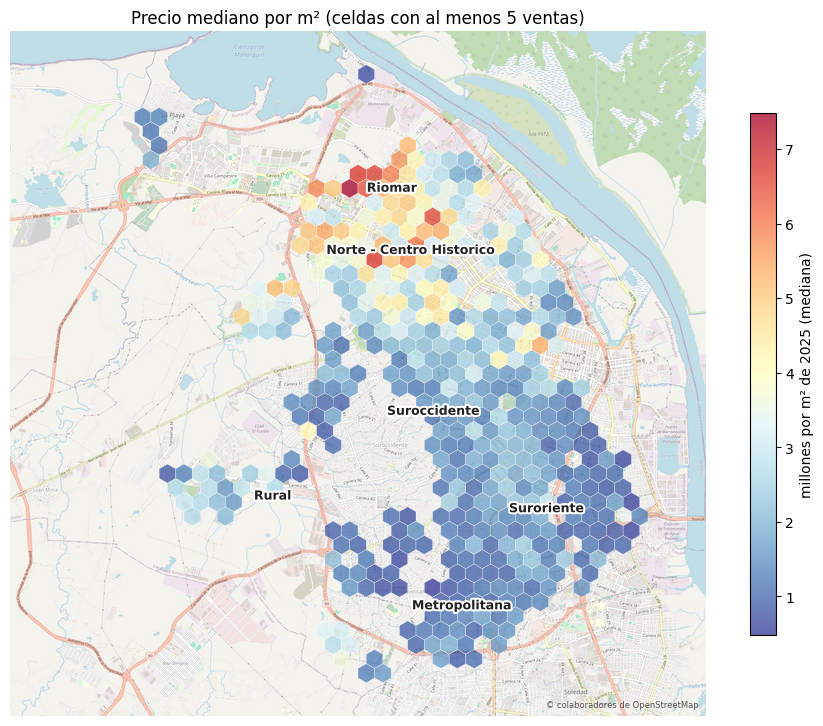

In [5]:
fig, ax = plt.subplots(figsize=(9, 9))
poner_fondo(ax)
hb = ax.hexbin(geo.lon, geo.lat, C=geo.pm2_M, reduce_C_function=np.median,
               gridsize=42, mincnt=5, cmap="RdYlBu_r", alpha=0.75, linewidths=0.3,
               edgecolors="white", extent=EXTENSION, zorder=2)
fig.colorbar(hb, ax=ax, shrink=0.6, label="millones por m² de 2025 (mediana)")

# nombre de cada localidad en el centro de sus predios
centros = geo.dropna(subset=["localidad"]).groupby("localidad").agg(lat=("lat", "median"), lon=("lon", "median"))
for loc, pos in centros.iterrows():
    ax.text(pos.lon, pos.lat, loc.title(), fontsize=9, fontweight="bold", ha="center", color="#222",
            zorder=3, path_effects=[pe.withStroke(linewidth=3, foreground="white")])

ax.set_title("Precio mediano por m² (celdas con al menos 5 ventas)")
plt.tight_layout()
plt.show()

In [6]:
geo["franja"] = pd.cut(geo.lat, bins=18)
perfil = geo.groupby("franja", observed=True).agg(n=("pm2_M", "size"), pm2=("pm2_M", "median")).query("n >= 30")
fig = go.Figure(go.Scatter(x=[iv.mid for iv in perfil.index], y=perfil.pm2, mode="lines+markers",
                           line=dict(color=ROJO, width=3), customdata=perfil.n,
                           hovertemplate="latitud %{x:.3f}: %{y:.2f} M por m² (%{customdata} ventas)<extra></extra>"))
fig.update_xaxes(title="latitud (de sur a norte)")
fig.update_yaxes(title="millones por m² (mediana)")
mostrar(fig, "El precio por m² sube de sur a norte", alto=400)

print("Spearman con el precio por m²:  latitud", round(geo.lat.corr(geo.precio_m2_real, method="spearman"), 2),
      "  longitud", round(geo.lon.corr(geo.precio_m2_real, method="spearman"), 2))
q10, q90 = geo.lat.quantile([0.1, 0.9])
print("El 10% más al norte cuesta", round(geo[geo.lat >= q90].precio_m2_real.median() /
                                         geo[geo.lat <= q10].precio_m2_real.median(), 1), "veces el m² del 10% más al sur")

Spearman con el precio por m²:  latitud 0.55   longitud -0.28
El 10% más al norte cuesta 1.9 veces el m² del 10% más al sur


El precio por m² sube de sur a norte: la latitud tiene una correlación de 0,55 con el
precio por m² y el 10% más al norte cuesta 1,9 veces el m² del 10% más al sur. La subida
no es lineal (se dispara en el norte), así que en el modelo las coordenadas funcionan
mejor en métodos como árboles o vecinos cercanos.

## Estrato en el mapa

In [7]:
e = geo[geo.estrato.isin(ESTRATOS)].sort_values("estrato_num")
fig = px.scatter_map(e, lat="lat", lon="lon", color="estrato_txt", opacity=0.7,
                     category_orders={"estrato_txt": NOMBRES_ESTRATO}, color_discrete_sequence=COLORES_ESTRATO,
                     custom_data=["barrio_txt", "precio_txt"], **MAPA)
fig.update_traces(marker=dict(size=5), hovertemplate="<b>%{customdata[0]}</b><br>Precio: %{customdata[1]}<extra></extra>")
fig.update_layout(legend=dict(title="", itemsizing="constant", x=0.01, y=0.98, bgcolor="rgba(255,255,255,0.85)"))
ajustar(fig, "Estrato de cada venta (clic en la leyenda para ocultar o mostrar)").show()

t = pd.crosstab(viv.localidad, viv.estrato_num)
chi2, p, gl, v = v_de_cramer(t)
anotar("¿El estrato depende de la localidad?", "Chi-cuadrado de independencia", chi2, p, f"V de Cramér = {v:.2f}")

Chi-cuadrado de independencia: estadístico = 15,172.472   p = < 0,001   V de Cramér = 0.53


Los estratos 5 y 6 están casi solo en el norte y los 1 y 2 en el sur y el occidente.
El estrato está muy asociado a la localidad (V de Cramér = 0,53).

## Dependencia espacial

In [8]:
muestra = geo.sample(n=min(6000, len(geo)), random_state=42)
nn = NearestNeighbors(n_neighbors=11, metric="haversine").fit(np.radians(muestra[["lat", "lon"]]))
_, idx = nn.kneighbors(np.radians(muestra[["lat", "lon"]]))
valores = np.log10(muestra.precio_m2_real.to_numpy())

def moran(v, vecinos_idx):
    z = v - v.mean()
    return (z * z[vecinos_idx].mean(axis=1)).sum() / (z ** 2).sum()

I = moran(valores, idx[:, 1:])
rng = np.random.default_rng(42)
azar = np.array([moran(rng.permutation(valores), idx[:, 1:]) for _ in range(999)])
p = (np.sum(azar >= I) + 1) / (len(azar) + 1)
print(f"I de Moran: {I:.3f}   (al barajar los precios, el máximo fue {azar.max():.3f})")
anotar("¿El precio por m² depende del de los vecinos?", "I de Moran (999 permutaciones)", I, p, "")

vecinos = valores[idx[:, 1:]].mean(axis=1)
fig = px.scatter(x=vecinos, y=valores, opacity=0.25, labels={"x": "log10 precio/m² de las 10 vecinas",
                                                             "y": "log10 precio/m² de la vivienda"})
fig.update_traces(marker=dict(size=4, color=AZUL), hoverinfo="skip", hovertemplate=None)
fig.add_scatter(x=[vecinos.min(), vecinos.max()], y=[vecinos.min(), vecinos.max()], mode="lines",
                line=dict(color="black", dash="dash"), showlegend=False)
mostrar(fig, f"Precio de cada vivienda frente al de sus vecinas (r = {np.corrcoef(valores, vecinos)[0, 1]:.2f})", alto=500)

I de Moran: 0.590   (al barajar los precios, el máximo fue 0.037)
I de Moran (999 permutaciones): estadístico = 0.590   p = 0,001   


El I de Moran es 0,59: el precio de una vivienda se parece mucho al de sus vecinas, y
barajando los precios al azar nunca pasó de 0,04. Para el modelo, eso significa usar el
precio de las vecinas como variable (calculado solo con los datos de entrenamiento) y
validar por zonas, no solo al azar.